# Resume Parser and Job Description Matching System

**Objective:** Extract key information (name, contact details, skills, education, experience, projects, certifications, languages) from a resume using NLP and regular expressions, then compare it with a job description to calculate a skill match score and give a recommendation.

**Tools used:** Python, spaCy, PyPDF2, python-docx, pandas, regex, matplotlib, ReportLab

## 1. Environment Setup
### 1.1 Install Required Libraries

In [1]:
# Code 1
!pip install spacy PyPDF2 python-docx pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 15.4 MB/s eta 0:00:00


### 1.2 Download the spaCy Language Model

In [2]:
# Code 2
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### 1.3 Import Libraries

In [3]:
# Code 3
import spacy
import PyPDF2
import docx
import pandas as pd

print("All libraries installed successfully!")

All libraries installed successfully!


## 2. Sample Resume (Text Format)
### 2.1 Create the Sample Resume

In [4]:
# Code 4
sample_resume = """
Harshitha S
Email: harshitha@gmail.com
Phone: 9876543210

SKILLS
Python, Java, SQL, HTML, CSS, JavaScript, React, Machine Learning, NLP, Git, GitHub, Pandas, NumPy

EDUCATION
B.Tech in Computer Science and Engineering

EXPERIENCE
Student Internship in Software Development

PROJECTS
1. Resume Parser and Job Description Matching System
2. Student Management System

CERTIFICATIONS
Python Programming Certificate
Machine Learning Certificate

LANGUAGES
English, Telugu, Hindi
"""

print("Sample resume created successfully!")

Sample resume created successfully!


### 2.2 Save the Resume as a Text File

In [5]:
# Code 5

with open("sample_resume.txt", "w") as file:
    file.write(sample_resume)

print("Sample resume saved as a text file!")

Sample resume saved as a text file!


### 2.3 Read the Resume from the Text File

In [6]:
# Code 6

with open("sample_resume.txt", "r") as file:
    resume_text = file.read()

print(resume_text)


Harshitha S
Email: harshitha@gmail.com
Phone: 9876543210

SKILLS
Python, Java, SQL, HTML, CSS, JavaScript, React, Machine Learning, NLP, Git, GitHub, Pandas, NumPy

EDUCATION
B.Tech in Computer Science and Engineering

EXPERIENCE
Student Internship in Software Development

PROJECTS
1. Resume Parser and Job Description Matching System
2. Student Management System

CERTIFICATIONS
Python Programming Certificate
Machine Learning Certificate

LANGUAGES
English, Telugu, Hindi



## 3. NLP Processing with spaCy
### 3.1 Load the spaCy Model and Process the Resume

In [7]:
# Code 7

import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp(resume_text)

print("Resume text processed successfully using spaCy!")

Resume text processed successfully using spaCy!


### 3.2 Named Entity Recognition (NER)

In [8]:
# Code 8

print("Named Entities:")
for ent in doc.ents:
    print(ent.text, "->", ent.label_)

Named Entities:
Harshitha S
Email -> ORG
9876543210 -> CARDINAL
Java -> PERSON
SQL -> ORG
HTML -> ORG
CSS -> ORG
JavaScript -> ORG
React -> GPE
Machine Learning -> PERSON
NLP -> ORG
Git -> PERSON
GitHub -> PRODUCT
Pandas -> PERSON
NumPy -> GPE
Computer Science and Engineering -> ORG
1 -> CARDINAL
Resume Parser -> PERSON
2 -> CARDINAL
Student Management System -> ORG
Python Programming Certificate
Machine Learning Certificate

 -> ORG
English -> NORP
Hindi
 -> PERSON


## 4. Personal Information Extraction
### 4.1 Extract Email Address

In [9]:
# Code 9

import re

email = re.search(r'[\w\.-]+@[\w\.-]+\.\w+', resume_text)

if email:
    print("Email:", email.group())
else:
    print("Email not found")

Email: harshitha@gmail.com


### 4.2 Extract Phone Number

In [10]:
# Code 10

phone = re.search(r'(\+91[\s-]?)?[6-9]\d{9}', resume_text)

if phone:
    print("Phone:", phone.group())
else:
    print("Phone number not found")

Phone: 9876543210


### 4.3 Extract Candidate Name

In [11]:
# Code 11

lines = [line.strip() for line in resume_text.split("\n") if line.strip()]

name = lines[0]

print("Name:", name)

Name: Harshitha S


## 5. Skills Extraction
### 5.1 Identify Skills from the Resume

In [12]:
# Code 12

skills_list = [
    "Python", "Java", "SQL", "HTML", "CSS", "JavaScript",
    "React", "Machine Learning", "NLP", "Git", "GitHub",
    "Pandas", "NumPy"
]

found_skills = []

for skill in skills_list:
    if skill.lower() in resume_text.lower():
        found_skills.append(skill)

print("Skills found:")
for skill in found_skills:
    print("-", skill)

Skills found:
- Python
- Java
- SQL
- HTML
- CSS
- JavaScript
- React
- Machine Learning
- NLP
- Git
- GitHub
- Pandas
- NumPy


## 6. Resume Section Extraction
### 6.1 Extract Education

In [13]:
# Code 13

education_section = re.search(
    r'EDUCATION(.*?)(?=EXPERIENCE|PROJECTS|CERTIFICATIONS|LANGUAGES|$)',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if education_section:
    education = education_section.group(1).strip()
    print("Education:")
    print(education)
else:
    print("Education details not found")

Education:
B.Tech in Computer Science and Engineering


### 6.2 Extract Experience

In [14]:
# Code 14

experience_section = re.search(
    r'EXPERIENCE(.*?)(?=PROJECTS|CERTIFICATIONS|LANGUAGES|$)',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if experience_section:
    experience = experience_section.group(1).strip()
    print("Experience:")
    print(experience)
else:
    print("Experience details not found")

Experience:
Student Internship in Software Development


### 6.3 Extract Projects

In [15]:
# Code 15

projects_section = re.search(
    r'PROJECTS(.*?)(?=CERTIFICATIONS|LANGUAGES|$)',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if projects_section:
    projects = projects_section.group(1).strip()
    print("Projects:")
    print(projects)
else:
    print("Project details not found")

Projects:
1. Resume Parser and Job Description Matching System
2. Student Management System


### 6.4 Extract Certifications

In [16]:
# Code 16

certifications_section = re.search(
    r'CERTIFICATIONS(.*?)(?=LANGUAGES|$)',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if certifications_section:
    certifications = certifications_section.group(1).strip()
    print("Certifications:")
    print(certifications)
else:
    print("Certification details not found")

Certifications:
Python Programming Certificate
Machine Learning Certificate


### 6.5 Extract Languages

In [17]:
# Code 17

languages_section = re.search(
    r'LANGUAGES(.*)$',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if languages_section:
    languages = [
        lang.strip()
        for lang in languages_section.group(1).split(",")
        if lang.strip()
    ]

    print("Languages:")
    for lang in languages:
        print("-", lang)
else:
    print("Language details not found")

Languages:
- English
- Telugu
- Hindi


## 7. Structured Resume Data
### 7.1 Combine All Extracted Details into a Dictionary

In [18]:
# Code 18

parsed_resume = {
    "Name": name,
    "Email": email.group() if email else "Not found",
    "Phone": phone.group() if phone else "Not found",
    "Skills": found_skills,
    "Education": education if education_section else "Not found",
    "Experience": experience if experience_section else "Not found",
    "Projects": projects if projects_section else "Not found",
    "Certifications": certifications if certifications_section else "Not found",
    "Languages": languages if languages_section else "Not found"
}

for key, value in parsed_resume.items():
    print(f"\n{key}:")
    print(value)


Name:
Harshitha S

Email:
harshitha@gmail.com

Phone:
9876543210

Skills:
['Python', 'Java', 'SQL', 'HTML', 'CSS', 'JavaScript', 'React', 'Machine Learning', 'NLP', 'Git', 'GitHub', 'Pandas', 'NumPy']

Education:
B.Tech in Computer Science and Engineering

Experience:
Student Internship in Software Development

Projects:
1. Resume Parser and Job Description Matching System
2. Student Management System

Certifications:
Python Programming Certificate
Machine Learning Certificate

Languages:
['English', 'Telugu', 'Hindi']


### 7.2 Organise Details into Sections

In [19]:
# Code 19

resume_sections = {
    "Personal Information": {
        "Name": parsed_resume["Name"],
        "Email": parsed_resume["Email"],
        "Phone": parsed_resume["Phone"]
    },
    "Professional Information": {
        "Skills": parsed_resume["Skills"],
        "Education": parsed_resume["Education"],
        "Experience": parsed_resume["Experience"]
    },
    "Additional Information": {
        "Projects": parsed_resume["Projects"],
        "Certifications": parsed_resume["Certifications"],
        "Languages": parsed_resume["Languages"]
    }
}

for section, details in resume_sections.items():
    print(f"\n{section}:")
    for key, value in details.items():
        print(f"{key}: {value}")


Personal Information:
Name: Harshitha S
Email: harshitha@gmail.com
Phone: 9876543210

Professional Information:
Skills: ['Python', 'Java', 'SQL', 'HTML', 'CSS', 'JavaScript', 'React', 'Machine Learning', 'NLP', 'Git', 'GitHub', 'Pandas', 'NumPy']
Education: B.Tech in Computer Science and Engineering
Experience: Student Internship in Software Development

Additional Information:
Projects: 1. Resume Parser and Job Description Matching System
2. Student Management System
Certifications: Python Programming Certificate
Machine Learning Certificate
Languages: ['English', 'Telugu', 'Hindi']


## 8. Resume Statistics
### 8.1 Resume Summary

In [20]:
# Code 20

resume_summary = {
    "Name": parsed_resume["Name"],
    "Total Skills": len(parsed_resume["Skills"]),
    "Total Projects": 2,
    "Total Certifications": 2,
    "Total Languages": len(parsed_resume["Languages"])
}

print("Resume Summary:")
for key, value in resume_summary.items():
    print(f"{key}: {value}")

Resume Summary:
Name: Harshitha S
Total Skills: 13
Total Projects: 2
Total Certifications: 2
Total Languages: 3


### 8.2 Count Total Skills

In [21]:
# Code 21

total_skills = len(parsed_resume["Skills"])

print("Total number of skills extracted:", total_skills)

Total number of skills extracted: 13


### 8.3 Count Total Projects

In [22]:
# Code 22

total_projects = len(parsed_resume["Projects"].split("\n"))

print("Total number of projects:", total_projects)

Total number of projects: 2


### 8.4 Count Total Certifications

In [23]:
# Code 23

total_certifications = len(parsed_resume["Certifications"].split("\n"))

print("Total number of certifications:", total_certifications)

Total number of certifications: 2


### 8.5 Count Total Languages

In [24]:
# Code 24

total_languages = len(parsed_resume["Languages"])

print("Total number of languages:", total_languages)

Total number of languages: 3


### 8.6 Combine Statistics

In [25]:
# Code 25

resume_statistics = {
    "Total Skills": total_skills,
    "Total Projects": total_projects,
    "Total Certifications": total_certifications,
    "Total Languages": total_languages
}

print("Resume Statistics:")
for key, value in resume_statistics.items():
    print(f"{key}: {value}")

Resume Statistics:
Total Skills: 13
Total Projects: 2
Total Certifications: 2
Total Languages: 3


## 9. Skills Presentation
### 9.1 Skills as a Single String

In [26]:
# Code 26

skills_string = ", ".join(parsed_resume["Skills"])

print("Skills:")
print(skills_string)

Skills:
Python, Java, SQL, HTML, CSS, JavaScript, React, Machine Learning, NLP, Git, GitHub, Pandas, NumPy


### 9.2 Skills Table

In [27]:
# Code 27

skills_table = pd.DataFrame({
    "Skill Number": range(1, len(parsed_resume["Skills"]) + 1),
    "Skill": parsed_resume["Skills"]
})

print(skills_table)

    Skill Number             Skill
0              1            Python
1              2              Java
2              3               SQL
3              4              HTML
4              5               CSS
5              6        JavaScript
6              7             React
7              8  Machine Learning
8              9               NLP
9             10               Git
10            11            GitHub
11            12            Pandas
12            13             NumPy


## 10. Resume Completeness Analysis
### 10.1 Check Available and Missing Sections

In [28]:
# Code 28

important_sections = [
    "Name",
    "Email",
    "Phone",
    "Skills",
    "Education",
    "Experience",
    "Projects",
    "Certifications",
    "Languages"
]

print("Resume Section Check:")

for section in important_sections:
    if parsed_resume.get(section):
        print(f"{section}: Available")
    else:
        print(f"{section}: Missing")

Resume Section Check:
Name: Available
Email: Available
Phone: Available
Skills: Available
Education: Available
Experience: Available
Projects: Available
Certifications: Available
Languages: Available


### 10.2 Calculate the Completeness Score

In [29]:
# Code 29

resume_completeness = (
    len([section for section in important_sections if parsed_resume.get(section)])
    / len(important_sections)
) * 100

print("Resume Completeness Score:", resume_completeness, "%")

Resume Completeness Score: 100.0 %


## 11. Final Resume Report
### 11.1 Generate the Report

In [30]:
# Code 30

final_resume_report = {
    "Candidate Name": parsed_resume["Name"],
    "Email": parsed_resume["Email"],
    "Phone": parsed_resume["Phone"],
    "Total Skills": total_skills,
    "Total Projects": total_projects,
    "Total Certifications": total_certifications,
    "Total Languages": total_languages,
    "Resume Completeness": f"{resume_completeness}%"
}

print("Final Resume Report:")

for key, value in final_resume_report.items():
    print(f"{key}: {value}")

Final Resume Report:
Candidate Name: Harshitha S
Email: harshitha@gmail.com
Phone: 9876543210
Total Skills: 13
Total Projects: 2
Total Certifications: 2
Total Languages: 3
Resume Completeness: 100.0%


### 11.2 Convert the Report to a DataFrame

In [31]:
# Code 31

resume_analysis = pd.DataFrame([final_resume_report])

print(resume_analysis)

  Candidate Name                Email       Phone  Total Skills  \
0    Harshitha S  harshitha@gmail.com  9876543210            13   

   Total Projects  Total Certifications  Total Languages Resume Completeness  
0               2                     2                3              100.0%  


### 11.3 Save the Report as a CSV File

In [32]:
# Code 32

resume_analysis.to_csv("resume_analysis.csv", index=False)

print("Resume analysis saved successfully as resume_analysis.csv")

Resume analysis saved successfully as resume_analysis.csv


### 11.4 Verify the CSV File

In [33]:
# Code 33

import os

if os.path.exists("resume_analysis.csv"):
    print("resume_analysis.csv file exists successfully!")
else:
    print("resume_analysis.csv file not found.")

resume_analysis.csv file exists successfully!


### 11.5 Resume Analysis Summary

In [34]:
# Code 34

print("Resume Parser Analysis Completed Successfully!")

print("\nCandidate:", parsed_resume["Name"])
print("Skills:", total_skills)
print("Projects:", total_projects)
print("Certifications:", total_certifications)
print("Languages:", total_languages)
print("Completeness:", resume_completeness, "%")

Resume Parser Analysis Completed Successfully!

Candidate: Harshitha S
Skills: 13
Projects: 2
Certifications: 2
Languages: 3
Completeness: 100.0 %


## 12. Resume in PDF Format
### 12.1 Install ReportLab

In [35]:
# Code 35

!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 14.7 MB/s eta 0:00:00


### 12.2 Create a Sample Resume PDF

In [36]:
# Code 36

from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas

pdf_file = "sample_resume.pdf"

c = canvas.Canvas(pdf_file, pagesize=A4)

c.setFont("Helvetica-Bold", 16)
c.drawString(50, 800, "Harshitha S")

c.setFont("Helvetica", 11)
c.drawString(50, 775, "Email: harshitha@gmail.com")
c.drawString(50, 755, "Phone: 9876543210")

c.setFont("Helvetica-Bold", 12)
c.drawString(50, 720, "SKILLS")

c.setFont("Helvetica", 11)
c.drawString(50, 700, skills_string)

c.setFont("Helvetica-Bold", 12)
c.drawString(50, 665, "EDUCATION")

c.setFont("Helvetica", 11)
c.drawString(50, 645, "B.Tech in Computer Science and Engineering")

c.setFont("Helvetica-Bold", 12)
c.drawString(50, 610, "EXPERIENCE")

c.setFont("Helvetica", 11)
c.drawString(50, 590, "Student Internship in Software Development")

c.setFont("Helvetica-Bold", 12)
c.drawString(50, 555, "PROJECTS")

c.setFont("Helvetica", 11)
c.drawString(50, 535, "1. Resume Parser and Job Description Matching System")
c.drawString(50, 515, "2. Student Management System")

c.setFont("Helvetica-Bold", 12)
c.drawString(50, 480, "CERTIFICATIONS")

c.setFont("Helvetica", 11)
c.drawString(50, 460, "Python Programming Certificate")
c.drawString(50, 440, "Machine Learning Certificate")

c.setFont("Helvetica-Bold", 12)
c.drawString(50, 405, "LANGUAGES")

c.setFont("Helvetica", 11)
c.drawString(50, 385, "English, Telugu, Hindi")

c.save()

print("Sample resume PDF created successfully!")

Sample resume PDF created successfully!


### 12.3 Extract Text from the PDF using PyPDF2

In [37]:
# Code 37

import PyPDF2

with open("sample_resume.pdf", "rb") as file:
    pdf_reader = PyPDF2.PdfReader(file)
    pdf_resume_text = ""

    for page in pdf_reader.pages:
        pdf_resume_text += page.extract_text() or ""

print("Text extracted from PDF successfully!")
print(pdf_resume_text)

Text extracted from PDF successfully!
Harshitha S
Email: harshitha@gmail.com
Phone: 9876543210
SKILLS
Python, Java, SQL, HTML, CSS, JavaScript, React, Machine Learning, NLP, Git, GitHub, Pandas, NumPy
EDUCATION
B.Tech in Computer Science and Engineering
EXPERIENCE
Student Internship in Software Development
PROJECTS
1. Resume Parser and Job Description Matching System
2. Student Management System
CERTIFICATIONS
Python Programming Certificate
Machine Learning Certificate
LANGUAGES
English, Telugu, Hindi



### 12.4 Use the PDF Text as the Resume Text

In [38]:
# Code 38

resume_text = pdf_resume_text

print("Resume text updated with PDF extracted text successfully!")

Resume text updated with PDF extracted text successfully!


## 13. NLP Processing of the PDF Resume
### 13.1 Process the PDF Text with spaCy

In [39]:
# Code 39

doc = nlp(resume_text)

print("PDF resume text processed successfully using spaCy!")

PDF resume text processed successfully using spaCy!


### 13.2 Named Entities from the PDF Resume

In [40]:
# Code 40

print("Named Entities from PDF Resume:")

for ent in doc.ents:
    print(ent.text, "->", ent.label_)

Named Entities from PDF Resume:
Harshitha S
Email -> ORG
9876543210 -> CARDINAL
Java -> PERSON
SQL -> ORG
HTML -> ORG
CSS -> ORG
JavaScript -> ORG
React -> GPE
Machine Learning -> PERSON
NLP -> ORG
Git -> PERSON
GitHub -> PRODUCT
Pandas -> PERSON
NumPy -> GPE
Computer Science and Engineering -> ORG
1 -> CARDINAL
Resume Parser -> PERSON
2 -> CARDINAL
Student Management System -> ORG
Python Programming Certificate
Machine Learning Certificate
LANGUAGES -> ORG
English -> NORP
Hindi
 -> PERSON


## 14. Information Extraction from the PDF Resume
### 14.1 Extract Email Address

In [41]:
# Code 41

import re

email = re.search(r'[\w\.-]+@[\w\.-]+\.\w+', resume_text)

if email:
    print("Email:", email.group())
else:
    print("Email not found")

Email: harshitha@gmail.com


### 14.2 Extract Phone Number

In [42]:
# Code 42

phone = re.search(r'(\+91[\s-]?)?[6-9]\d{9}', resume_text)

if phone:
    print("Phone:", phone.group())
else:
    print("Phone number not found")

Phone: 9876543210


### 14.3 Extract Candidate Name

In [43]:
# Code 43

lines = [line.strip() for line in resume_text.split("\n") if line.strip()]

name = lines[0]

print("Name:", name)

Name: Harshitha S


### 14.4 Extract Skills

In [44]:
# Code 44

skills_list = [
    "Python", "Java", "SQL", "HTML", "CSS", "JavaScript",
    "React", "Machine Learning", "NLP", "Git", "GitHub",
    "Pandas", "NumPy"
]

found_skills = []

for skill in skills_list:
    if skill.lower() in resume_text.lower():
        found_skills.append(skill)

print("Skills found:")
for skill in found_skills:
    print("-", skill)

Skills found:
- Python
- Java
- SQL
- HTML
- CSS
- JavaScript
- React
- Machine Learning
- NLP
- Git
- GitHub
- Pandas
- NumPy


### 14.5 Extract Education

In [45]:
# Code 45

education_section = re.search(
    r'EDUCATION(.*?)(?=EXPERIENCE|PROJECTS|CERTIFICATIONS|LANGUAGES|$)',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if education_section:
    education = education_section.group(1).strip()
    print("Education:")
    print(education)
else:
    print("Education details not found")

Education:
B.Tech in Computer Science and Engineering


### 14.6 Extract Experience

In [46]:
# Code 46

experience_section = re.search(
    r'EXPERIENCE(.*?)(?=PROJECTS|CERTIFICATIONS|LANGUAGES|$)',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if experience_section:
    experience = experience_section.group(1).strip()
    print("Experience:")
    print(experience)
else:
    print("Experience details not found")

Experience:
Student Internship in Software Development


### 14.7 Extract Projects

In [47]:
# Code 47

projects_section = re.search(
    r'PROJECTS(.*?)(?=CERTIFICATIONS|LANGUAGES|$)',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if projects_section:
    projects = projects_section.group(1).strip()
    print("Projects:")
    print(projects)
else:
    print("Project details not found")

Projects:
1. Resume Parser and Job Description Matching System
2. Student Management System


### 14.8 Extract Certifications

In [48]:
# Code 48

certifications_section = re.search(
    r'CERTIFICATIONS(.*?)(?=LANGUAGES|$)',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if certifications_section:
    certifications = certifications_section.group(1).strip()
    print("Certifications:")
    print(certifications)
else:
    print("Certification details not found")

Certifications:
Python Programming Certificate
Machine Learning Certificate


### 14.9 Extract Languages

In [49]:
# Code 49

languages_section = re.search(
    r'LANGUAGES(.*)$',
    resume_text,
    re.DOTALL | re.IGNORECASE
)

if languages_section:
    languages = [
        lang.strip()
        for lang in languages_section.group(1).split(",")
        if lang.strip()
    ]

    print("Languages:")
    for lang in languages:
        print("-", lang)
else:
    print("Language details not found")

Languages:
- English
- Telugu
- Hindi


## 15. PDF Resume Analysis
### 15.1 Structured PDF Resume Data

In [50]:
# Code 50

parsed_pdf_resume = {
    "Name": name,
    "Email": email.group() if email else "Not found",
    "Phone": phone.group() if phone else "Not found",
    "Skills": found_skills,
    "Education": education if education_section else "Not found",
    "Experience": experience if experience_section else "Not found",
    "Projects": projects if projects_section else "Not found",
    "Certifications": certifications if certifications_section else "Not found",
    "Languages": languages if languages_section else "Not found"
}

for key, value in parsed_pdf_resume.items():
    print(f"\n{key}:")
    print(value)


Name:
Harshitha S

Email:
harshitha@gmail.com

Phone:
9876543210

Skills:
['Python', 'Java', 'SQL', 'HTML', 'CSS', 'JavaScript', 'React', 'Machine Learning', 'NLP', 'Git', 'GitHub', 'Pandas', 'NumPy']

Education:
B.Tech in Computer Science and Engineering

Experience:
Student Internship in Software Development

Projects:
1. Resume Parser and Job Description Matching System
2. Student Management System

Certifications:
Python Programming Certificate
Machine Learning Certificate

Languages:
['English', 'Telugu', 'Hindi']


### 15.2 Convert to a DataFrame

In [51]:
# Code 51

parsed_pdf_df = pd.DataFrame([parsed_pdf_resume])

print(parsed_pdf_df)

          Name                Email       Phone  \
0  Harshitha S  harshitha@gmail.com  9876543210   

                                              Skills  \
0  [Python, Java, SQL, HTML, CSS, JavaScript, Rea...   

                                    Education  \
0  B.Tech in Computer Science and Engineering   

                                   Experience  \
0  Student Internship in Software Development   

                                            Projects  \
0  1. Resume Parser and Job Description Matching ...   

                                      Certifications                 Languages  
0  Python Programming Certificate\nMachine Learni...  [English, Telugu, Hindi]  


### 15.3 Count Total Skills

In [52]:
# Code 52

total_pdf_skills = len(parsed_pdf_resume["Skills"])

print("Total number of skills extracted from PDF:", total_pdf_skills)

Total number of skills extracted from PDF: 13


### 15.4 Resume Completeness Score

In [53]:
# Code 53

pdf_resume_completeness = (
    len([
        section for section in important_sections
        if parsed_pdf_resume.get(section)
    ]) / len(important_sections)
) * 100

print("PDF Resume Completeness Score:", pdf_resume_completeness, "%")

PDF Resume Completeness Score: 100.0 %


### 15.5 Save the PDF Resume Analysis as CSV

In [54]:
# Code 54

pdf_resume_analysis = {
    "Candidate Name": parsed_pdf_resume["Name"],
    "Email": parsed_pdf_resume["Email"],
    "Phone": parsed_pdf_resume["Phone"],
    "Total Skills": total_pdf_skills,
    "Education": parsed_pdf_resume["Education"],
    "Experience": parsed_pdf_resume["Experience"],
    "Total Projects": len(parsed_pdf_resume["Projects"].split("\n")),
    "Total Certifications": len(parsed_pdf_resume["Certifications"].split("\n")),
    "Total Languages": len(parsed_pdf_resume["Languages"]),
    "Resume Completeness": f"{pdf_resume_completeness}%"
}

pdf_resume_analysis_df = pd.DataFrame([pdf_resume_analysis])

pdf_resume_analysis_df.to_csv("pdf_resume_analysis.csv", index=False)

print("PDF resume analysis saved successfully as pdf_resume_analysis.csv")

PDF resume analysis saved successfully as pdf_resume_analysis.csv


### 15.6 Verify the CSV File

In [55]:
# Code 55

import os

if os.path.exists("pdf_resume_analysis.csv"):
    print("pdf_resume_analysis.csv file exists successfully!")
else:
    print("pdf_resume_analysis.csv file not found.")

pdf_resume_analysis.csv file exists successfully!


## 16. Job Description Analysis
### 16.1 Create a Sample Job Description

In [56]:
# Code 56

job_description = """
PYTHON DEVELOPER

We are looking for a Python Developer with knowledge of Python, SQL,
Machine Learning, Pandas, NumPy, Git, and Data Structures.

The candidate should have good problem-solving skills and experience
in developing software projects.

Knowledge of HTML, CSS, JavaScript, and React is an added advantage.
"""

print("Sample job description created successfully!")
print(job_description)

Sample job description created successfully!

PYTHON DEVELOPER

We are looking for a Python Developer with knowledge of Python, SQL,
Machine Learning, Pandas, NumPy, Git, and Data Structures.

The candidate should have good problem-solving skills and experience
in developing software projects.

Knowledge of HTML, CSS, JavaScript, and React is an added advantage.



### 16.2 Process the Job Description with spaCy

In [57]:
# Code 57

job_doc = nlp(job_description)

print("Job description processed successfully using spaCy!")

Job description processed successfully using spaCy!


### 16.3 Define the Job Skills List

In [58]:
# Code 58

job_skills_list = [
    "Python", "Java", "SQL", "HTML", "CSS", "JavaScript",
    "React", "Machine Learning", "NLP", "Git", "GitHub",
    "Pandas", "NumPy", "Data Structures"
]

print("Job skill list created successfully!")

Job skill list created successfully!


### 16.4 Extract Required Skills from the Job Description

In [59]:
# Code 59

required_skills = []

for skill in job_skills_list:
    pattern = r'\b' + re.escape(skill) + r'\b'

    if re.search(pattern, job_description, re.IGNORECASE):
        required_skills.append(skill)

print("Required skills in Job Description:")
for skill in required_skills:
    print("-", skill)

Required skills in Job Description:
- Python
- SQL
- HTML
- CSS
- JavaScript
- React
- Machine Learning
- Git
- Pandas
- NumPy
- Data Structures


## 17. Resume–Job Matching
### 17.1 Find Matched Skills

In [60]:
# Code 60

matched_skills = []

for skill in required_skills:
    if skill.lower() in [s.lower() for s in found_skills]:
        matched_skills.append(skill)

print("Skills matched with the Resume:")
for skill in matched_skills:
    print("-", skill)

Skills matched with the Resume:
- Python
- SQL
- HTML
- CSS
- JavaScript
- React
- Machine Learning
- Git
- Pandas
- NumPy


### 17.2 Find Missing Skills

In [61]:
# Code 61

missing_skills = []

for skill in required_skills:
    if skill.lower() not in [s.lower() for s in found_skills]:
        missing_skills.append(skill)

print("Skills missing from the Resume:")
for skill in missing_skills:
    print("-", skill)

Skills missing from the Resume:
- Data Structures


### 17.3 Calculate the Match Score

In [62]:
# Code 62

match_score = (len(matched_skills) / len(required_skills)) * 100

print("Resume-JD Match Score:", round(match_score, 2), "%")

Resume-JD Match Score: 90.91 %


### 17.4 Matched and Missing Percentages

In [63]:
# Code 63

matched_percentage = (len(matched_skills) / len(required_skills)) * 100
missing_percentage = (len(missing_skills) / len(required_skills)) * 100

print("Matched Skills Percentage:", round(matched_percentage, 2), "%")
print("Missing Skills Percentage:", round(missing_percentage, 2), "%")

Matched Skills Percentage: 90.91 %
Missing Skills Percentage: 9.09 %


### 17.5 Skill Matching Summary

In [64]:
# Code 64

matching_summary = {
    "Total Required Skills": len(required_skills),
    "Matched Skills": len(matched_skills),
    "Missing Skills": len(missing_skills),
    "Match Score": f"{round(match_score, 2)}%",
    "Matched Skills Percentage": f"{round(matched_percentage, 2)}%",
    "Missing Skills Percentage": f"{round(missing_percentage, 2)}%"
}

print("Skill Matching Summary:")
for key, value in matching_summary.items():
    print(key + ":", value)

Skill Matching Summary:
Total Required Skills: 11
Matched Skills: 10
Missing Skills: 1
Match Score: 90.91%
Matched Skills Percentage: 90.91%
Missing Skills Percentage: 9.09%


### 17.6 Skill Matching Table

In [65]:
# Code 65

skill_matching_data = {
    "Required Skills": required_skills,
    "Status": [
        "Matched" if skill in matched_skills else "Missing"
        for skill in required_skills
    ]
}

skill_matching_df = pd.DataFrame(skill_matching_data)

print(skill_matching_df)

     Required Skills   Status
0             Python  Matched
1                SQL  Matched
2               HTML  Matched
3                CSS  Matched
4         JavaScript  Matched
5              React  Matched
6   Machine Learning  Matched
7                Git  Matched
8             Pandas  Matched
9              NumPy  Matched
10   Data Structures  Missing


### 17.7 Save Skill Matching Results as CSV

In [66]:
# Code 66

skill_matching_df.to_csv("skill_matching_results.csv", index=False)

print("Skill matching results saved successfully as skill_matching_results.csv")

Skill matching results saved successfully as skill_matching_results.csv


### 17.8 Verify the CSV File

In [67]:
# Code 67

import os

if os.path.exists("skill_matching_results.csv"):
    print("skill_matching_results.csv file exists successfully!")
else:
    print("skill_matching_results.csv file not found.")

skill_matching_results.csv file exists successfully!


## 18. Final Matching Report
### 18.1 Generate the Report

In [68]:
# Code 68

final_matching_report = {
    "Candidate Name": parsed_pdf_resume["Name"],
    "Total Required Skills": len(required_skills),
    "Matched Skills": ", ".join(matched_skills),
    "Missing Skills": ", ".join(missing_skills),
    "Match Score": f"{round(match_score, 2)}%",
    "Matched Percentage": f"{round(matched_percentage, 2)}%",
    "Missing Percentage": f"{round(missing_percentage, 2)}%"
}

print("Final Matching Report:")
for key, value in final_matching_report.items():
    print(key + ":", value)

Final Matching Report:
Candidate Name: Harshitha S
Total Required Skills: 11
Matched Skills: Python, SQL, HTML, CSS, JavaScript, React, Machine Learning, Git, Pandas, NumPy
Missing Skills: Data Structures
Match Score: 90.91%
Matched Percentage: 90.91%
Missing Percentage: 9.09%


### 18.2 Save the Report as CSV

In [69]:
# Code 69

final_matching_df = pd.DataFrame([final_matching_report])

final_matching_df.to_csv("final_matching_report.csv", index=False)

print("Final matching report saved successfully as final_matching_report.csv")

Final matching report saved successfully as final_matching_report.csv


### 18.3 Verify the CSV File

In [70]:
# Code 70

import os

if os.path.exists("final_matching_report.csv"):
    print("final_matching_report.csv file exists successfully!")
else:
    print("final_matching_report.csv file not found.")

final_matching_report.csv file exists successfully!


## 19. Job Matching Recommendation
### 19.1 Decide the Match Level (Strong / Moderate / Low)

In [71]:
# Code 71

if match_score >= 80:
    recommendation = "Strong Match"
elif match_score >= 60:
    recommendation = "Moderate Match"
else:
    recommendation = "Low Match"

print("Job Matching Recommendation:", recommendation)

Job Matching Recommendation: Strong Match


### 19.2 Add the Recommendation to the Report

In [72]:
# Code 72

final_matching_report["Recommendation"] = recommendation

print("Updated Final Matching Report:")
for key, value in final_matching_report.items():
    print(key + ":", value)

Updated Final Matching Report:
Candidate Name: Harshitha S
Total Required Skills: 11
Matched Skills: Python, SQL, HTML, CSS, JavaScript, React, Machine Learning, Git, Pandas, NumPy
Missing Skills: Data Structures
Match Score: 90.91%
Matched Percentage: 90.91%
Missing Percentage: 9.09%
Recommendation: Strong Match


### 19.3 Save the Updated Report

In [73]:
# Code 73

final_matching_df = pd.DataFrame([final_matching_report])

final_matching_df.to_csv("final_matching_report.csv", index=False)

print("Updated final matching report saved successfully!")

Updated final matching report saved successfully!


### 19.4 Display the Verified Report

In [74]:
# Code 74

final_report_display = pd.read_csv("final_matching_report.csv")

print("Verified Final Matching Report:\n")
display(final_report_display)

Verified Final Matching Report:



,Candidate Name,Total Required Skills,Matched Skills,Missing Skills,Match Score,Matched Percentage,Missing Percentage,Recommendation
0,Harshitha S,11,"Python, SQL, HTML, CSS, JavaScript, React, Mac...",Data Structures,90.91%,90.91%,9.09%,Strong Match


## 20. Visualization
### 20.1 Count Matched vs Missing Skills

In [75]:
# Code 75

skill_status_counts = {
    "Matched": len(matched_skills),
    "Missing": len(missing_skills)
}

print("Skill Status:")
for status, count in skill_status_counts.items():
    print(status + ":", count)

Skill Status:
Matched: 10
Missing: 1


### 20.2 Skill Matching Bar Chart

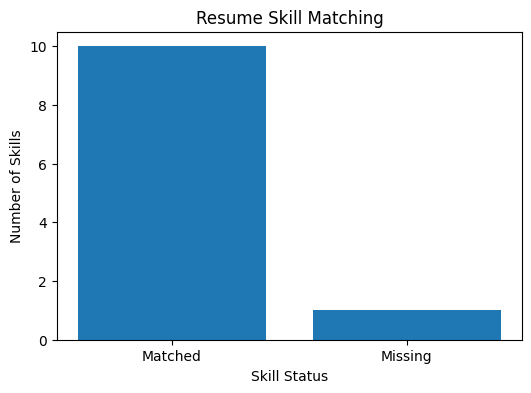

In [76]:
# Code 76

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(skill_status_counts.keys(), skill_status_counts.values())
plt.title("Resume Skill Matching")
plt.xlabel("Skill Status")
plt.ylabel("Number of Skills")
plt.show()

## 21. Final Project Summary
### 21.1 Print the Summary

In [77]:
# Code 77

print("Final Project Summary")
print("----------------------")
print("Candidate Name:", parsed_pdf_resume["Name"])
print("Required Skills:", len(required_skills))
print("Matched Skills:", len(matched_skills))
print("Missing Skills:", len(missing_skills))
print("Match Score:", round(match_score, 2), "%")
print("Recommendation:", recommendation)

Final Project Summary
----------------------
Candidate Name: Harshitha S
Required Skills: 11
Matched Skills: 10
Missing Skills: 1
Match Score: 90.91 %
Recommendation: Strong Match


### 21.2 Save the Summary as CSV

In [78]:
# Code 78

final_project_summary = {
    "Candidate Name": parsed_pdf_resume["Name"],
    "Required Skills": len(required_skills),
    "Matched Skills": len(matched_skills),
    "Missing Skills": len(missing_skills),
    "Match Score": round(match_score, 2),
    "Recommendation": recommendation
}

final_project_summary_df = pd.DataFrame([final_project_summary])

final_project_summary_df.to_csv("final_project_summary.csv", index=False)

print("Final project summary saved successfully as final_project_summary.csv")

Final project summary saved successfully as final_project_summary.csv


### 21.3 Display the Verified Summary

In [79]:
# Code 79

final_summary_display = pd.read_csv("final_project_summary.csv")

print("Verified Final Project Summary:\n")
display(final_summary_display)

Verified Final Project Summary:



,Candidate Name,Required Skills,Matched Skills,Missing Skills,Match Score,Recommendation
0,Harshitha S,11,10,1,90.91,Strong Match


## 22. Final File Verification
### 22.1 Check That All Output Files Exist

In [80]:
# Code 80

import os

final_files = [
    "sample_resume.pdf",
    "pdf_resume_analysis.csv",
    "skill_matching_results.csv",
    "final_matching_report.csv",
    "final_project_summary.csv"
]

print("Final Project File Verification:")
print("-------------------------------")

for file in final_files:
    if os.path.exists(file):
        print(file, "-> Available")
    else:
        print(file, "-> Missing")

Final Project File Verification:
-------------------------------
sample_resume.pdf -> Available
pdf_resume_analysis.csv -> Available
skill_matching_results.csv -> Available
final_matching_report.csv -> Available
final_project_summary.csv -> Available


## Conclusion

The system parsed a resume from both text and PDF formats, extracted structured details, compared the candidate's skills with a job description, and produced a match score, a recommendation, a chart and CSV reports.